In [1]:
from google.colab import files

uploaded = files.upload()

Saving StudentsPerformance[1].csv to StudentsPerformance[1].csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df = pd.read_csv("StudentsPerformance[1].csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print("Mean of Math Score:", df["math score"].mean())
print("Mean of Reading Score:", df["reading score"].mean())
print("Mean of Writing Score:", df["writing score"].mean())

Mean of Math Score: 66.089
Mean of Reading Score: 69.169
Mean of Writing Score: 68.054


In [11]:
print("Median of Math Score:", df["math score"].median())
print("Median of Reading Score:", df["reading score"].median())
print("Median of Writing Score:", df["writing score"].median())

Median of Math Score: 66.0
Median of Reading Score: 70.0
Median of Writing Score: 69.0


In [12]:
print("Mode of Math Score:")
print(df["math score"].mode())

print("Mode of Reading Score:")
print(df["reading score"].mode())

print("Mode of Writing Score:")
print(df["writing score"].mode())

Mode of Math Score:
0    65
Name: math score, dtype: int64
Mode of Reading Score:
0    72
Name: reading score, dtype: int64
Mode of Writing Score:
0    74
Name: writing score, dtype: int64


In [13]:
print("Variance of Math Score:", df["math score"].var())
print("Variance of Reading Score:", df["reading score"].var())
print("Variance of Writing Score:", df["writing score"].var())

Variance of Math Score: 229.91899799799847
Variance of Reading Score: 213.1656046046047
Variance of Writing Score: 230.90799199199168


In [14]:
print("Standard Deviation of Math Score:", df["math score"].std())
print("Standard Deviation of Reading Score:", df["reading score"].std())
print("Standard Deviation of Writing Score:", df["writing score"].std())

Standard Deviation of Math Score: 15.163080096009468
Standard Deviation of Reading Score: 14.60019193725222
Standard Deviation of Writing Score: 15.195657010869642


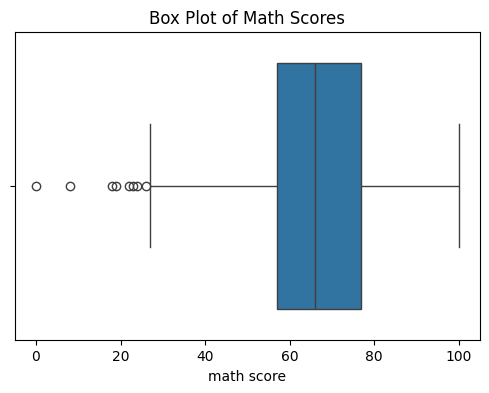

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["math score"])

plt.title("Box Plot of Math Scores")

plt.show()

In [16]:
Q1 = df["math score"].quantile(0.25)
Q3 = df["math score"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 57.0
Q3: 77.0
IQR: 20.0
Lower Limit: 27.0
Upper Limit: 107.0


In [17]:
outliers = df[(df["math score"] < lower_limit) | (df["math score"] > upper_limit)]

outliers

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38
787,female,group B,some college,standard,none,19,38,32
842,female,group B,high school,free/reduced,completed,23,44,36
980,female,group B,high school,free/reduced,none,8,24,23


In [18]:
df = df[(df["math score"] >= lower_limit) &
        (df["math score"] <= upper_limit)]

print("New Dataset Shape:", df.shape)

New Dataset Shape: (992, 8)


In [19]:
correlation = df.corr(numeric_only=True)

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.806838       0.789300
reading score    0.806838       1.000000       0.952531
writing score    0.789300       0.952531       1.000000


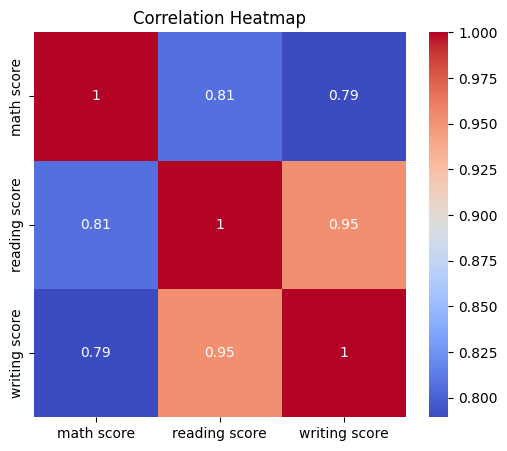

In [20]:
plt.figure(figsize=(6,5))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

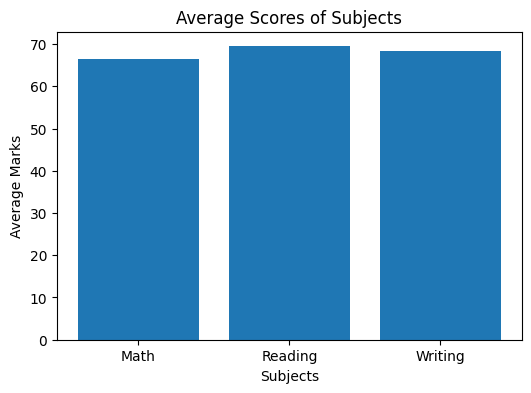

In [21]:
subjects = ["Math", "Reading", "Writing"]

scores = [
    df["math score"].mean(),
    df["reading score"].mean(),
    df["writing score"].mean()
]

plt.figure(figsize=(6,4))

plt.bar(subjects, scores)

plt.title("Average Scores of Subjects")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.show()

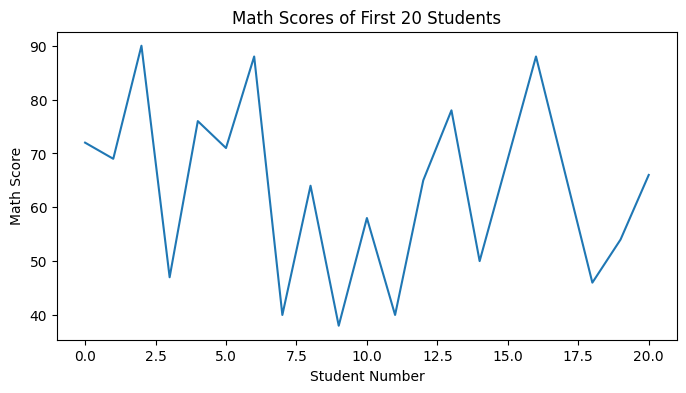

In [22]:
plt.figure(figsize=(8,4))

plt.plot(df["math score"].head(20))

plt.title("Math Scores of First 20 Students")
plt.xlabel("Student Number")
plt.ylabel("Math Score")

plt.show()

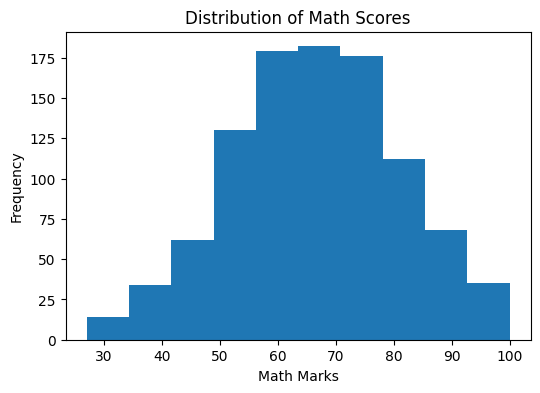

In [23]:
plt.figure(figsize=(6,4))

plt.hist(df["math score"], bins=10)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Marks")
plt.ylabel("Frequency")

plt.show()

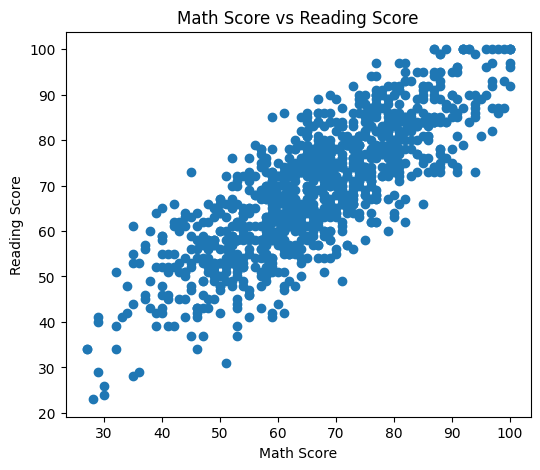

In [24]:
plt.figure(figsize=(6,5))

plt.scatter(df["math score"], df["reading score"])

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

## Student Performance Analysis – EDA Summary

### Objective

The objective of this project is to analyze student exam performance and identify the factors affecting student scores using Python, Pandas, NumPy, and Matplotlib.

---

### Dataset Information

* **Total Records:** 1000
* **Total Columns:** 8
* **Numeric Columns:** Math Score, Reading Score, Writing Score
* **Categorical Columns:** Gender, Race/Ethnicity, Parental Level of Education, Lunch, Test Preparation Course

---

### Data Cleaning

* Checked for **missing values** using `df.isnull().sum()`
* No missing values were found.
* Checked for **duplicate records** using `df.duplicated().sum()`
* No duplicate rows were present.

---

### Statistical Analysis

| Measure            | Math   | Reading | Writing |
| ------------------ | ------ | ------- | ------- |
| Mean               | 66.09  | 69.17   | 68.05   |
| Median             | 66     | 70      | 69      |
| Mode               | 65     | 72      | 74      |
| Variance           | 229.92 | 213.17  | 230.91  |
| Standard Deviation | 15.16  | 14.60   | 15.20   |

---

### Outlier Detection

* Outliers were detected using the **IQR (Interquartile Range) method**.
* A **box plot** was used to visualize unusual values in the Math Score column.
* The dataset was filtered to remove values outside the acceptable range.

---

### Correlation Analysis

| Variables         | Correlation |
| ----------------- | ----------- |
| Math & Reading    | 0.81        |
| Math & Writing    | 0.79        |
| Reading & Writing | 0.95        |

#### Observation

* Reading and Writing scores have a **very strong positive correlation**.
* Students who perform well in Reading generally also perform well in Writing.
* Math scores also show a strong positive relationship with both Reading and Writing scores.

---

### Visualizations Created

* **Bar Chart** – Compared average scores of Math, Reading, and Writing.
* **Line Chart** – Displayed score trends for the first 20 students.
* **Histogram** – Showed the distribution of Math scores.
* **Scatter Plot** – Demonstrated the relationship between Math and Reading scores.
* **Heatmap** – Visualized correlations between numeric variables.

---

### Key Insights

1. The average performance of students is around **66–69 marks** across all subjects.
2. Reading scores are slightly higher than Math and Writing scores.
3. Reading and Writing skills are highly connected.
4. Most students scored between **60 and 80 marks**.
5. Very few outliers were found in the dataset.
6. Students with better Reading performance tend to have better Writing performance as well.

---

### Conclusion

The exploratory data analysis successfully identified patterns in student performance. Reading and Writing scores are strongly related, indicating that language-related skills influence both subjects. The dataset was clean, with no missing or duplicate values, and the visualizations provided clear insights into score distributions and relationships between subjects. This analysis demonstrates how Python, Pandas, NumPy, Statistics, Correlation Analysis, Data Cleaning, EDA, and Matplotlib can be used effectively to study student performance data.
